In [1]:
# 1. Carga de Librerías y Dataset del TP2
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score, ConfusionMatrixDisplay
)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Carga del Dataset del TP2
csv_path = 'datos_concatenados.csv'
df_raw = pd.read_csv(csv_path)
print(f"Dataset del TP2 cargado exitosamente: {df_raw.shape[0]:,} filas.")

Dataset del TP2 cargado exitosamente: 64,295 filas.


Ejercicio 1: Partición Estratificada Train / Test

In [3]:
# Ejercicio 1: Partición estratificada Train/Test
# ---
# Construimos una representación limpia de variables clave a partir del dataset base.
df = df_raw.copy()

df['Primer_Par_Clean'] = pd.to_numeric(df['Primer.Par'], errors='coerce')
df['Segundo_Par_Clean'] = pd.to_numeric(df['Segundo.Par'], errors='coerce')
df['TPLab_Clean'] = pd.to_numeric(df['TPLab.'], errors='coerce')
df['Firma_Clean'] = pd.to_numeric(df['Firma'], errors='coerce')
df['FirmaCalc_Clean'] = pd.to_numeric(df['FirmaCalculada'], errors='coerce')
df['Asis_Clean'] = pd.to_numeric(df['Asis'], errors='coerce')
df['Score_Parciales'] = df[['Primer_Par_Clean', 'Segundo_Par_Clean']].fillna(0).sum(axis=1)
df['Diff_Parciales'] = df['Primer_Par_Clean'] - df['Segundo_Par_Clean']

df['Carrera_Nombre'] = df['Carrera_Nombre'].fillna('Sin Carrera')
df['Semestre'] = df['Semestre'].astype(str)

y = df['Aprobado'].astype(str).str.strip().str.upper().isin(['S', 'SI', '1', '1.0']).astype(int)

num_features = ['Primer_Par_Clean', 'Segundo_Par_Clean', 'Score_Parciales', 'Diff_Parciales', 'TPLab_Clean', 'Firma_Clean', 'FirmaCalc_Clean', 'Asis_Clean']
cat_features = ['Carrera_Nombre', 'Semestre']

X = df[num_features + cat_features]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"Distribución target train: {y_train.value_counts(normalize=True).to_dict()}")
print(f"Distribución target test: {y_test.value_counts(normalize=True).to_dict()}")

X_train shape: (51436, 10), X_test shape: (12859, 10)
Distribución target train: {1: 0.6066568162376546, 0: 0.39334318376234545}
Distribución target test: {1: 0.6066568162376546, 0: 0.39334318376234545}


## Ejercicio 2: Construcción del Preprocesador Profesional (`ColumnTransformer`)

Construye un `Pipeline` numérico con:
1. `SimpleImputer(strategy='median')`
2. `PolynomialFeatures(degree=2, include_bias=False)`
3. `StandardScaler()`

Y un `Pipeline` categórico con `SimpleImputer` y `OneHotEncoder(handle_unknown='ignore')`.


In [4]:
# Ejercicio 2: Preprocesador profesional
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

print("Preprocesador listo.")

Preprocesador listo.


## Ejercicio 3: Entrenamiento del Modelo y Búsqueda en Malla (`GridSearchCV`)

Ensambla `full_pipeline` con `LogisticRegression(class_weight='balanced', solver='lbfgs', max_iter=2000)`.
Configura `GridSearchCV` sobre el parámetro de regularización `C` en `[0.01, 0.1, 1.0, 10.0]` con `scoring='f1'`.


In [5]:
# Ejercicio 3: Entrenamiento del modelo y GridSearchCV
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='lbfgs', max_iter=2000, random_state=42, class_weight='balanced'))
])

param_grid = {'classifier__C': [0.01, 0.1, 1.0, 10.0]}
grid_search = GridSearchCV(
    full_pipeline,
    param_grid,
    cv=StratifiedKFold(n_splits=5),
    scoring='f1',
    n_jobs=1
)

grid_search.fit(X_train, y_train)
print(f"Mejor C: {grid_search.best_params_['classifier__C']}")
print(f"Mejor F1 CV: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

Mejor C: 0.1
Mejor F1 CV: 0.8835


## Ejercicio 4: Graficación de la Curva de Aprendizaje (`learning_curve`)

Calcula y grafica la curva de aprendizaje utilizando `learning_curve` sobre `X_train` y `y_train` con 10 tamaños de entrenamiento (`np.linspace(0.1, 1.0, 10)`).


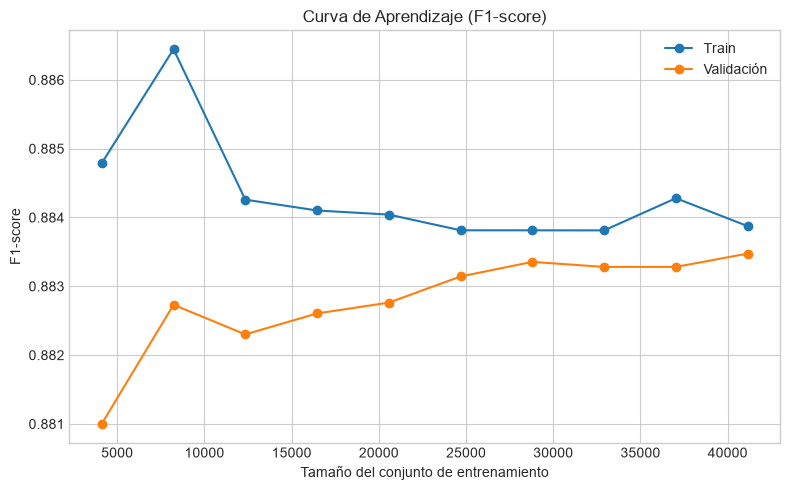

Train F1 mean: 0.8839
Validation F1 mean: 0.8835


In [6]:
# Ejercicio 4: Curva de aprendizaje
train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_train,
    y_train,
    cv=StratifiedKFold(n_splits=5),
    scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, label='Train', marker='o')
plt.plot(train_sizes, val_mean, label='Validación', marker='o')
plt.title('Curva de Aprendizaje (F1-score)')
plt.xlabel('Tamaño del conjunto de entrenamiento')
plt.ylabel('F1-score')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Train F1 mean: {train_mean[-1]:.4f}")
print(f"Validation F1 mean: {val_mean[-1]:.4f}")

## Ejercicio 5: Optimización del Umbral de Decisión y Evaluación de Desempeño

En el conjunto de prueba (`X_test`):
1. Obtén las probabilidades de aprobación `y_proba_test`.
2. Optimiza el umbral de decisión ($\tau^*$) entre `0.1` y `0.9` que maximiza el F1-Score.
3. Grafica la **Matriz de Confusión**, la **Curva ROC (AUC)** y la **Curva Precision-Recall**.


Umbral óptimo: 0.410
F1-score máximo: 0.8882
              precision    recall  f1-score   support

           0     0.8595    0.7691    0.8118      5058
           1     0.8598    0.9185    0.8882      7801

    accuracy                         0.8597     12859
   macro avg     0.8597    0.8438    0.8500     12859
weighted avg     0.8597    0.8597    0.8581     12859



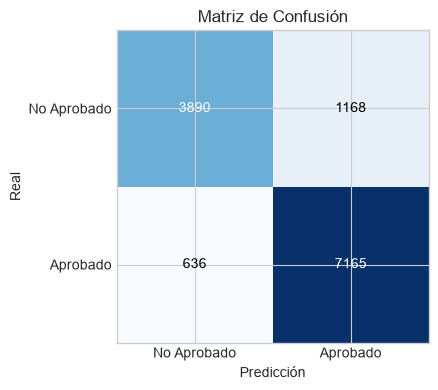

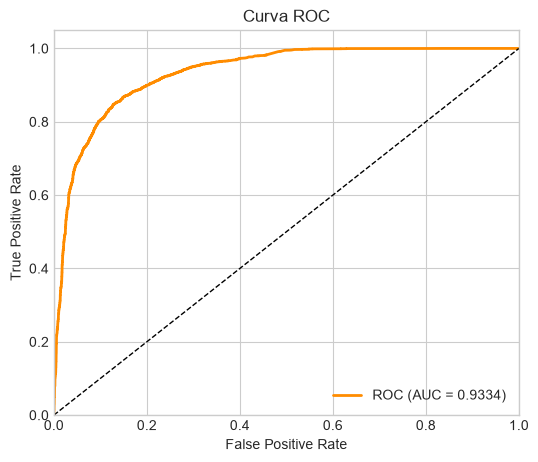

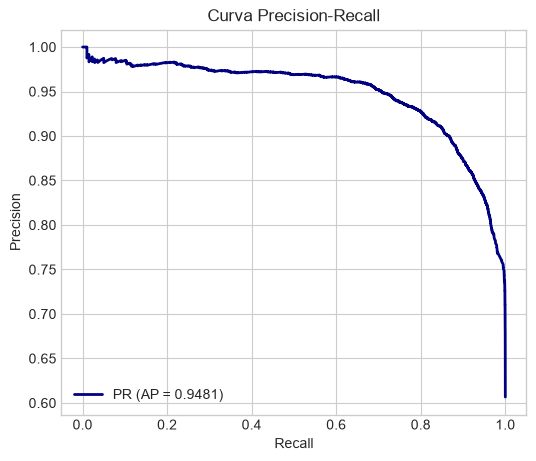

In [8]:
# Ejercicio 5: Optimización de umbral y métricas de desempeño
# ---
y_proba_test = best_model.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.1, 0.9, 81)
fscores = []
for thr in thresholds:
    y_pred_thr = (y_proba_test >= thr).astype(int)
    fscores.append(f1_score(y_test, y_pred_thr))

best_idx = np.argmax(fscores)
best_thresh = thresholds[best_idx]
y_pred_test = (y_proba_test >= best_thresh).astype(int)

print(f"Umbral óptimo: {best_thresh:.3f}")
print(f"F1-score máximo: {fscores[best_idx]:.4f}")
print(classification_report(y_test, y_pred_test, digits=4))

# Matriz de confusión sin depender de ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm, cmap='Blues')
ax.set_title('Matriz de Confusión')
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['No Aprobado', 'Aprobado'])
ax.set_yticklabels(['No Aprobado', 'Aprobado'])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.tight_layout()
plt.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
roc_auc = roc_auc_score(y_test, y_proba_test)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.4f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Curva Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_proba_test)
pr_auc = average_precision_score(y_test, y_proba_test)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'PR (AP = {pr_auc:.4f})', color='navy', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()